# Cost-Sensitive Fraud Detection — Analysis & Results

Visualizing the full pipeline: risk scoring → cost framework → expected loss optimization → 3-tier decision layer → model comparison → SHAP interpretability.

See `README.md` for the full narrative and sourced cost assumptions.

In [2]:
import sys
sys.path.append("..")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from src.cost_analysis import build_cost_matrix, get_fraud_amounts_for_index
from src.decision_layer import assign_risk_tier, find_block_threshold, summarize_decision_tiers
from src.expected_loss import compute_loss_curve
from src.interpretability import compute_shap_values
from src.risk_scoring import MODELS_DIR, load_model, score_transactions
from src.system_simulation import compute_do_nothing_baseline, compute_tier_system_cost, simulate_model_cost

sns.set_style("whitegrid")
%matplotlib inline

X_test, y_test = joblib.load(MODELS_DIR / "test_set.pkl")
amounts = get_fraud_amounts_for_index(y_test.index)
cost_matrix = build_cost_matrix(y_test)
print(cost_matrix.summary())

Cost matrix: False Negative ≈ $108.62 (avg missed fraud amount) | False Positive = $25.00 (manual review cost) | Cost ratio (FN:FP) ≈ 4.3:1


## 1. Expected Loss Across Thresholds

Why 0.21, not the default 0.5? This is the cost curve that answers that question.

*Note: this analysis uses XGBoost (the final model, selected in the model comparison below) rather than Random Forest. Absolute dollar figures here will differ slightly from the Random Forest-based numbers reported during earlier development steps in the README — the optimal threshold (0.21) happens to be the same for both models, but the resulting confusion matrix and cost differ.*

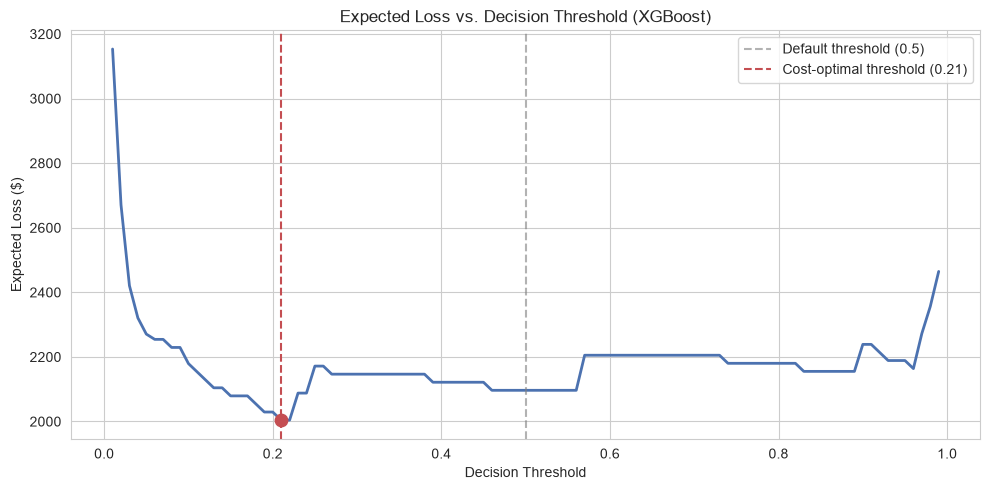

Cost-optimal threshold: 0.21 | Expected loss: $2,004.33


In [3]:
model = load_model("xgboost.pkl")
risk_scores = score_transactions(model, X_test)
loss_curve = compute_loss_curve(y_test, risk_scores, cost_matrix)

best_idx = loss_curve["expected_loss"].idxmin()
best_threshold = loss_curve.loc[best_idx, "threshold"]
best_loss = loss_curve.loc[best_idx, "expected_loss"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(loss_curve["threshold"], loss_curve["expected_loss"], color="#4C72B0", linewidth=2)
ax.axvline(0.5, color="gray", linestyle="--", alpha=0.6, label="Default threshold (0.5)")
ax.axvline(best_threshold, color="#C44E52", linestyle="--", label=f"Cost-optimal threshold ({best_threshold:.2f})")
ax.scatter([best_threshold], [best_loss], color="#C44E52", zorder=5, s=80)
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Expected Loss ($)")
ax.set_title("Expected Loss vs. Decision Threshold (XGBoost)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Cost-optimal threshold: {best_threshold:.2f} | Expected loss: ${best_loss:,.2f}")

## 2. Model Comparison by Total System Cost

Higher recall doesn't guarantee a better business outcome. This chart tests that directly.

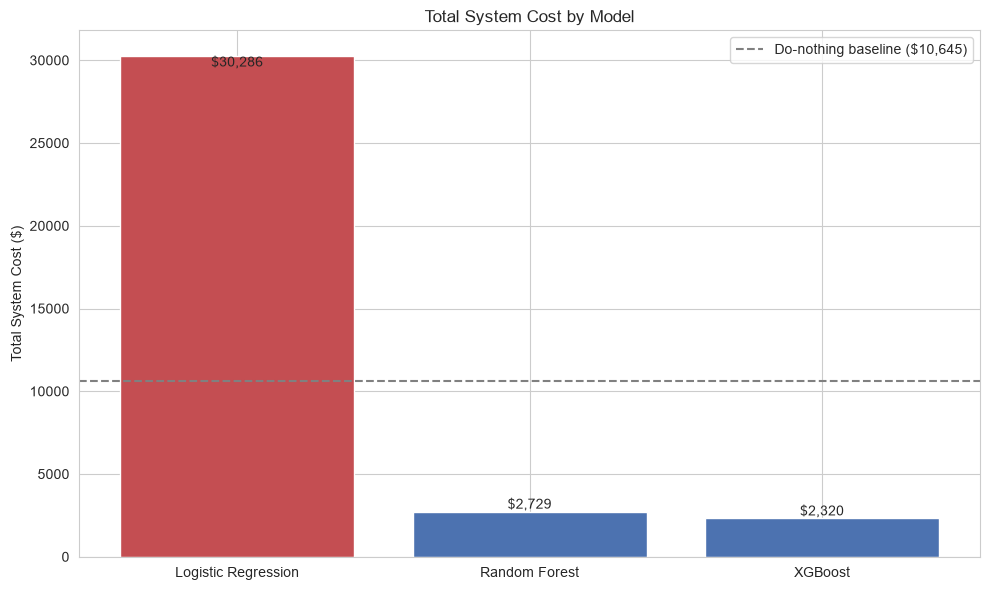

,model,fn_loss,review_cost,false_block_loss,total_cost
0,Logistic Regression,1832.72,850.0,27603.15,30285.87
1,Random Forest,1826.50,900.0,2.76,2729.26
2,XGBoost,1942.10,375.0,2.77,2319.87


In [4]:
model_files = {
    "Logistic Regression": "logistic_regression.pkl",
    "Random Forest": "random_forest.pkl",
    "XGBoost": "xgboost.pkl",
}

baseline = compute_do_nothing_baseline(y_test, amounts)
results = []
for label, filename in model_files.items():
    m = load_model(filename)
    result = simulate_model_cost(m, X_test, y_test, amounts, cost_matrix, label=label)
    results.append(result)

comparison_df = pd.DataFrame([
    {"model": r.label, "fn_loss": r.fn_loss, "review_cost": r.review_cost,
     "false_block_loss": r.false_block_loss, "total_cost": r.total_cost}
    for r in results
])

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#C44E52" if c > baseline.total_cost else "#4C72B0" for c in comparison_df["total_cost"]]
bars = ax.bar(comparison_df["model"], comparison_df["total_cost"], color=colors)
ax.axhline(baseline.total_cost, color="gray", linestyle="--", label=f"Do-nothing baseline (${baseline.total_cost:,.0f})")
ax.set_ylabel("Total System Cost ($)")
ax.set_title("Total System Cost by Model")
ax.legend()
for bar, cost in zip(bars, comparison_df["total_cost"]):
    ax.text(bar.get_x() + bar.get_width()/2, cost, f"${cost:,.0f}", ha="center", va="bottom" if cost < baseline.total_cost else "top")
plt.tight_layout()
plt.show()

comparison_df

Note: Logistic Regression (red) costs *more* than doing nothing at all — despite having the highest fraud recall of the three models. Its poor precision drives excessive auto-blocking of legitimate transactions.

## 3. Decision Tier Breakdown

How the 3-tier system (approve / review / block) splits the test set.

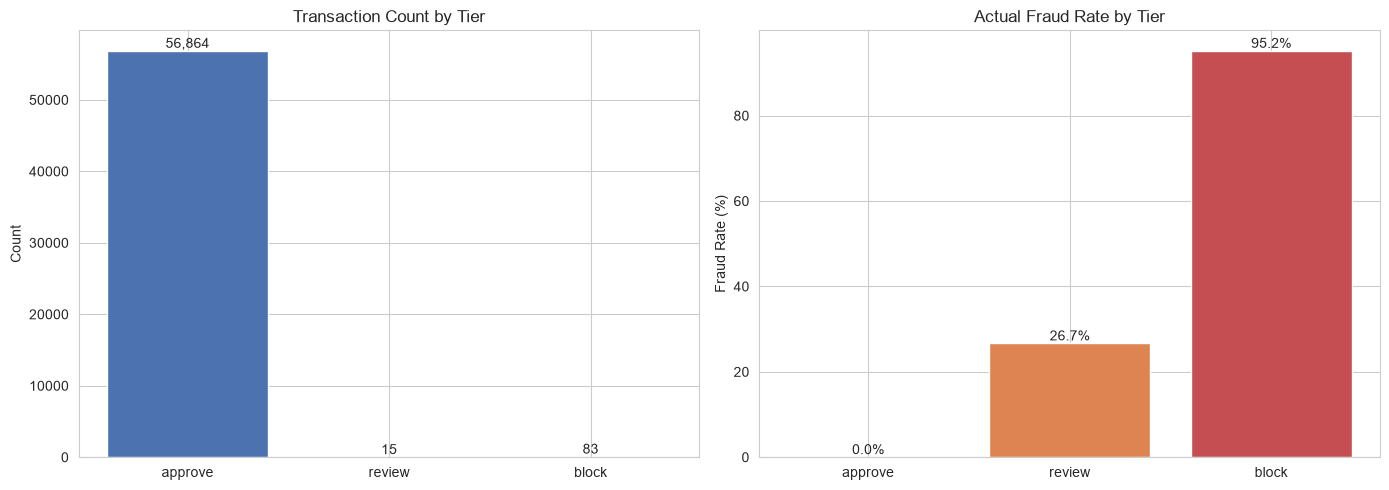

,tier,count,fraud_count,fraud_rate
0,approve,56864,15,0.000264
1,review,15,4,0.266667
2,block,83,79,0.951807


In [5]:
block_threshold = find_block_threshold(y_test, risk_scores, min_precision=0.95, min_threshold=best_threshold + 0.01)
tiers = assign_risk_tier(risk_scores, best_threshold, block_threshold)
tier_summaries = summarize_decision_tiers(y_test, tiers)

tier_df = pd.DataFrame([
    {"tier": s.tier, "count": s.count, "fraud_count": s.actual_fraud_count, "fraud_rate": s.fraud_rate()}
    for s in tier_summaries
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(tier_df["tier"], tier_df["count"], color=["#4C72B0", "#DD8452", "#C44E52"])
axes[0].set_title("Transaction Count by Tier")
axes[0].set_ylabel("Count")
for i, v in enumerate(tier_df["count"]):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

axes[1].bar(tier_df["tier"], tier_df["fraud_rate"] * 100, color=["#4C72B0", "#DD8452", "#C44E52"])
axes[1].set_title("Actual Fraud Rate by Tier")
axes[1].set_ylabel("Fraud Rate (%)")
for i, v in enumerate(tier_df["fraud_rate"] * 100):
    axes[1].text(i, v, f"{v:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

tier_df

## 4. SHAP Feature Importance

Which features drive the model's fraud predictions, and why.

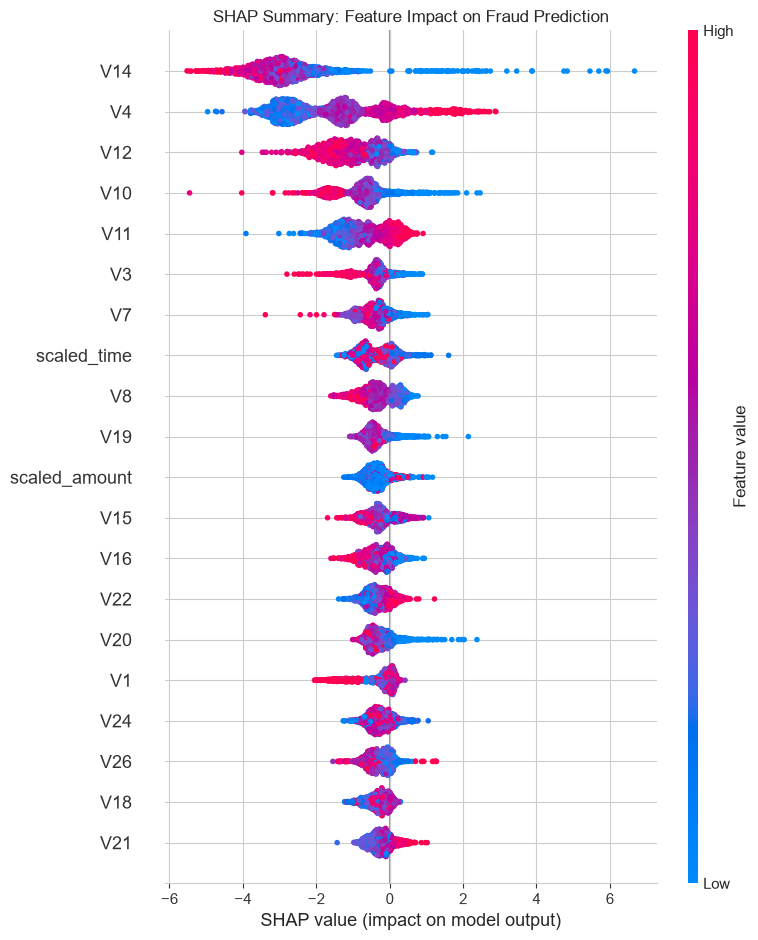

In [6]:
sample_X = X_test.sample(n=2000, random_state=42)
shap_values = compute_shap_values(model, sample_X)

shap.summary_plot(shap_values, sample_X, show=False)
plt.title("SHAP Summary: Feature Impact on Fraud Prediction")
plt.tight_layout()
plt.show()

## Summary

- **Cost-optimal threshold (0.21)** cuts expected loss by 15.4% versus the default 0.5 cutoff.
- **Model choice matters more than raw recall**: despite Logistic Regression having the highest fraud recall, it actually loses money relative to doing nothing at all due to poor precision — XGBoost, with more balanced precision/recall, minimizes total cost.
- **3-tier decisioning** keeps manual review to ~0.06% of transactions while catching the same fraud volume as the binary threshold.
- **SHAP confirms EDA findings**: `V14`, `V12`, and `V10` are consistently the strongest fraud signals across two independent methods (correlation and SHAP).

Full sourced methodology and cost assumptions are documented in the project [README](../README.md).